In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [3]:
import torch
import torch.nn as nn

class LidarPoseCNN(nn.Module):
    def __init__(self, T, n_rays, n_out=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3,5), padding=(1,2)),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=(3,5), padding=(1,2)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1,4)),
            nn.Conv2d(64, 64, kernel_size=(3,5), padding=(1,2)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1,4)),
        )

        # calcula automaticamente o tamanho do flatten
        with torch.no_grad():
            dummy = torch.zeros(1, 1, T, n_rays)
            out = self.features(dummy)
            flat_dim = out.view(1, -1).size(1)

        self.head = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.ReLU(),
            nn.Linear(256, n_out),
        )

    def forward(self, x):
        x = self.features(x)          # [B,C,T',N']
        x = x.view(x.size(0), -1)     # [B, flat_dim]
        return self.head(x)


In [4]:


DATASET_DIR = Path(r"C:\Users\User\Documents\IA_PROJECT\Archives\files_webot\IA_20252\controllers\lidar_dataset\dataset_lidar_pose")
T = 5  # tamanho da janela temporal (ajusta)

files = sorted(DATASET_DIR.glob("*.npz"))

class LidarSeqCnnDataset(Dataset):
    def __init__(self, files, T):
        self.files = files
        self.T = T

    def __len__(self):
        return len(self.files) - self.T + 1

    def __getitem__(self, idx):
        scans = []
        for k in range(self.T):
            d = np.load(self.files[idx + k])
            scans.append(d["lidar"])          # [N_rays]

        X = np.stack(scans, axis=0)           # [T, N_rays]
        X = torch.tensor(X, dtype=torch.float32).unsqueeze(0)  # [1, T, N_rays]

        pose = np.load(self.files[idx + self.T - 1])["pose"]
        y = torch.tensor(pose[:2], dtype=torch.float32)        # regressão (x,y)

        return X, y

dataset = LidarSeqCnnDataset(files, T)


In [5]:
n = len(dataset)
n_train = int(0.8 * n)
n_val = n - n_train
train_ds = torch.utils.data.Subset(dataset, range(0, n_train))
val_ds   = torch.utils.data.Subset(dataset, range(n_train, n))


BATCH_SIZE = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # importantíssimo no Windows
    pin_memory=False,   # desliga por enquanto
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)


In [6]:
N_RAYS = dataset[0][0].shape[-1]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = LidarPoseCNN(T=T, n_rays=N_RAYS, n_out=2).to(DEVICE)

criterion = nn.L1Loss()                 # MAE em (x,y)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [7]:
X0, y0 = dataset[0]
print("X0 shape:", X0.shape)  # [1, T, N_rays]

dummy = X0.unsqueeze(0).to(DEVICE)  # [1,1,T,N_rays]
with torch.no_grad():
    feat = model.features(dummy)
print("feat shape:", feat.shape)
print("feat numel:", feat.numel())



X0 shape: torch.Size([1, 5, 360])
feat shape: torch.Size([1, 64, 5, 22])
feat numel: 7040


In [8]:
def eval_pos_error(loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            pred = model(X)
            err = torch.linalg.norm(pred - y, dim=1)  # [B]
            total += err.sum().item()
    return total / len(loader.dataset)

def criterion(pred, y):
    return torch.linalg.norm(pred - y, dim=1).mean()



In [ ]:
from tqdm import tqdm

EPOCHS = 10

train_history = {"loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    # ---------- TREINO ----------
    model.train()
    total_train = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [TRAIN]")
    for X, y in pbar:
        X = X.to(DEVICE)          # [B,1,T,360]
        y = y.to(DEVICE)          # [B,2]

        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)   # <-- LOSS EUCLIDIANA
        loss.backward()
        optimizer.step()

        total_train += loss.item() * X.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = total_train / len(train_loader.dataset)
    train_history["loss"].append(train_loss)

    # ---------- VALIDAÇÃO ----------
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [VAL]")
        for X, y in pbar_val:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            pred = model(X)
            loss = criterion(pred, y)   # <-- LOSS EUCLIDIANA
            total_val += loss.item() * X.size(0)
            pbar_val.set_postfix(loss=f"{loss.item():.4f}")

    val_loss = total_val / len(val_loader.dataset)
    train_history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")


Epoch 1/10 [TRAIN]:   0%|          | 6/4372 [00:00<02:40, 27.25it/s, loss=1.5910]

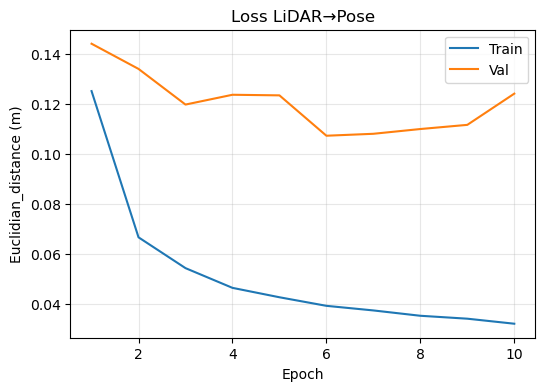

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)
plt.figure(figsize=(6,4))
plt.plot(epochs, train_history["loss"], label="Train")
plt.plot(epochs, train_history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Euclidian_distance (m)")
plt.title("Loss LiDAR→Pose")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
torch.save(model.state_dict(), "lidar_pose_cnn_temporal_2.pth")


In [ ]:
model.eval()
with torch.no_grad():
    for i in range(5):
        X, y = val_ds[i]          # um exemplo
        X = X.unsqueeze(0).to(DEVICE)   # [1,1,T,N_rays]
        y_pred = model(X).cpu().numpy()[0]
        y_true = y.numpy()
        err = np.linalg.norm(y_pred - y_true)

        print(f"sample {i}:")
        print(f"  true: {y_true}")
        print(f"  pred: {y_pred}")
        print(f"  erro: {err:.3f} m\n")


sample 0:
  true: [1.256814  1.5747566]
  pred: [1.210638  1.5763128]
  erro: 0.046 m

sample 1:
  true: [1.256807  1.5699534]
  pred: [1.2052095 1.5826447]
  erro: 0.053 m

sample 2:
  true: [1.2567997 1.5651516]
  pred: [1.2061392 1.590513 ]
  erro: 0.057 m

sample 3:
  true: [1.2567923 1.5603507]
  pred: [1.1991796 1.5852253]
  erro: 0.063 m

sample 4:
  true: [1.2567848 1.5555506]
  pred: [1.1968795 1.5783509]
  erro: 0.064 m



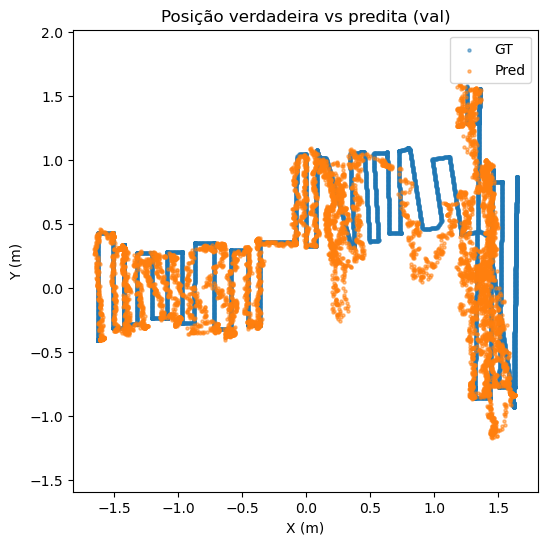

In [ ]:
model.eval()
pred_x, pred_y, true_x, true_y = [], [], [], []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        pred = model(X)
        pred_x.extend(pred[:,0].cpu().numpy())
        pred_y.extend(pred[:,1].cpu().numpy())
        true_x.extend(y[:,0].cpu().numpy())
        true_y.extend(y[:,1].cpu().numpy())

plt.figure(figsize=(6,6))
plt.scatter(true_x, true_y, s=5, label="GT", alpha=0.5)
plt.scatter(pred_x, pred_y, s=5, label="Pred", alpha=0.5)
plt.axis("equal")
plt.legend()
plt.title("Posição verdadeira vs predita (val)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()


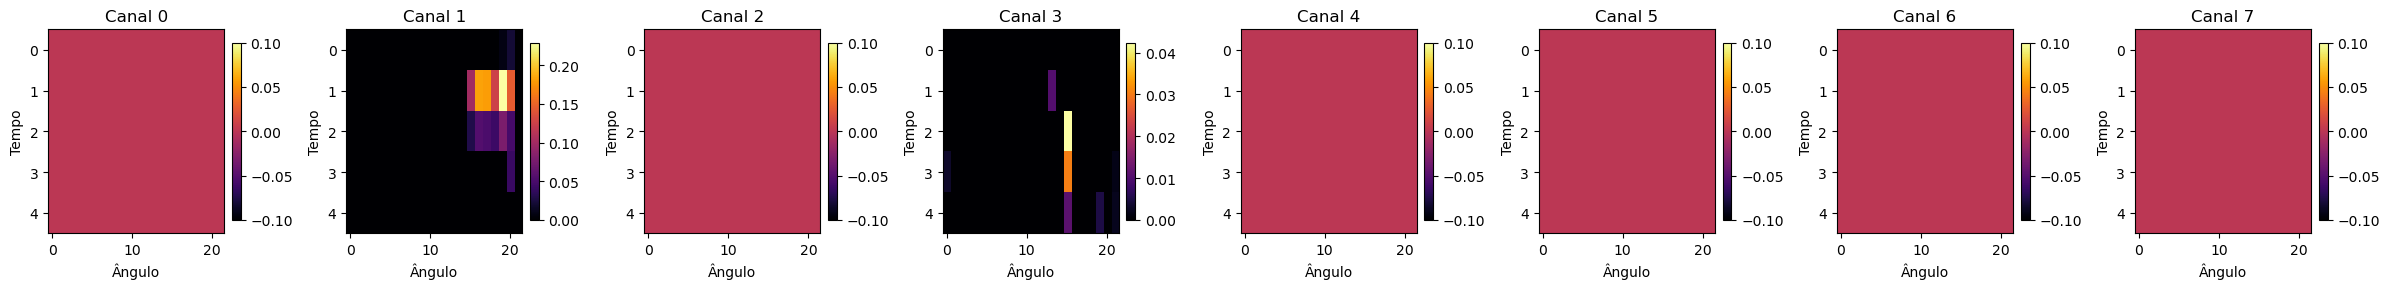

In [ ]:

X, y = val_ds[0]
Xb = X.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    feat = model.features(Xb).cpu().numpy()[0]  # [C,T',N']

C = feat.shape[0]
n_show = min(8, C)

fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
for i in range(n_show):
    ax = axes[i]
    im = ax.imshow(feat[i], aspect='auto', cmap='inferno')
    ax.set_title(f"Canal {i}")
    ax.set_xlabel("Ângulo")
    ax.set_ylabel("Tempo")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


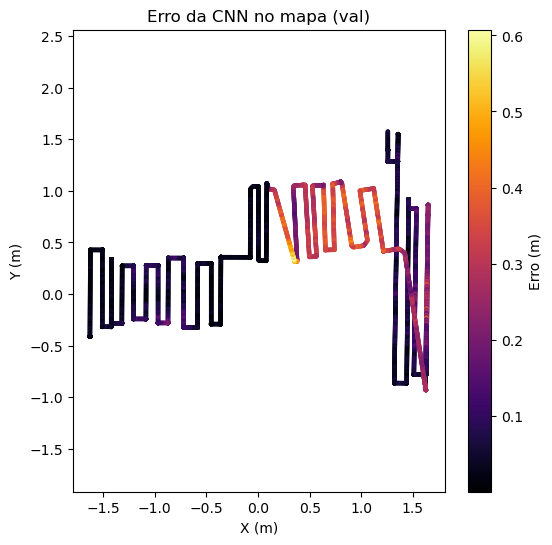

In [ ]:

model.eval()
xs, ys = [], []
errs = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        pred = model(X)
        err = torch.linalg.norm(pred - y, dim=1).cpu().numpy()   # [B]

        xs.extend(y[:,0].cpu().numpy())
        ys.extend(y[:,1].cpu().numpy())
        errs.extend(err)

xs = np.array(xs)
ys = np.array(ys)
errs = np.array(errs)

plt.figure(figsize=(6,6))
sc = plt.scatter(xs, ys, c=errs, s=5, cmap="inferno")
plt.colorbar(sc, label="Erro (m)")
plt.axis("equal")
plt.title("Erro da CNN no mapa (val)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()
